# Лекция. Экосистема

## § 1. Библиотеки 

Настоящий курс — это не программирование на Python. Это использование готовых библиотечных кодов для решения задач анализа данных и машинного обучения. Основные библиотеки, которые при этом применяются:
- numpy — работа c массивами; 
- pandas — надстройка над numpy, работа с датафремами; 
- matplotlib — визуализация; 
- seaborn — надстройка над matplotlib и pandas, визуализация;
- sklearn — модели.

In [1]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set(style = 'whitegrid', palette = 'pastel')
import sklearn as skl

Эти и другие импорты будут использоваться при запуске каждого ipynb.

## § 2. Простейший датафрейм

Создавать датафреймы вручную приходится довольно-таки редко, но, тем не менее, это полезный навык. Есть несколько способов создать датафрейм «с нуля». Здесь он создан из словаря (о словарях и других структурах — в следующих лекциях).

In [2]:
data = {
    'Имя': ['Анна', 'Борис', 'Анна', 'Мария', 'Алексей'],
    'Возраст': [20, 22, 19, 21, 23],
    'Средний балл': [4.5, 3.8, 4.2, 4.9, 3.5],
    'Курс': [2, 3, 2, 4, 3]
}

df = pd.DataFrame(data)
display(df)

,Имя,Возраст,Средний балл,Курс
0,Анна,20,4.5,2
1,Борис,22,3.8,3
2,Анна,19,4.2,2
3,Мария,21,4.9,4
4,Алексей,23,3.5,3


Вообще, можно строить датафреймы по-разному. Вот, например, другой метод, когда списки значений последовательно присоединяются как именованные столбцы:

In [3]:
df = pd.DataFrame()
df['Имя'] = ['Анна', 'Борис', 'Анна', 'Мария', 'Алексей']
df['Возраст'] = [20, 22, 19, 21, 23]
df['Средний балл'] = [4.5, 3.8, 4.2, 4.9, 3.5]
df['Курс'] = [2, 3, 2, 4, 3]
df

,Имя,Возраст,Средний балл,Курс
0,Анна,20,4.5,2
1,Борис,22,3.8,3
2,Анна,19,4.2,2
3,Мария,21,4.9,4
4,Алексей,23,3.5,3


>#### Задание
> 1) Сравните выводы ячеек при использовании `print` и `display`.
> 2) Добавьте еще одного студента.

Итак, датафрейм — это таблица, в которой записаны числа или строки (на самом деле, там может быть записано что угодно, но чаще всего это числа и строки). По умолчанию строки нумеруются от 0 и далее по порядку (при желании это можно изменить), а столбцы, как правило обладают именами (это тоже можно изменить). 

Вывести информацию о данных датафрейма можно следующим образом:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Имя           5 non-null      object 
 1   Возраст       5 non-null      int64  
 2   Средний балл  5 non-null      float64
 3   Курс          5 non-null      int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 292.0+ bytes


Видим, что данные относятся к разным типам: целые числа, десятичные дроби и строки. Можно посмотреть статистики для числовых данных:

In [5]:
df.describe()

,Возраст,Средний балл,Курс
count,5.000000,5.000000,5.00000
mean,21.000000,4.180000,2.80000
std,1.581139,0.554076,0.83666
min,19.000000,3.500000,2.00000
25%,20.000000,3.800000,2.00000
50%,21.000000,4.200000,3.00000
75%,22.000000,4.500000,3.00000
max,23.000000,4.900000,4.00000


А можно — для данных какого-то конкретного типа:

In [6]:
df.describe(include='float64')

,Средний балл
count,5.000000
mean,4.180000
std,0.554076
min,3.500000
25%,3.800000
50%,4.200000
75%,4.500000
max,4.900000


>#### Задание
Выведите статистики 1) для строк, 2) для целых чисел и 3) для десятичных дробей.

Датафрейм можно сохранить в виде файла csv. Можно и в других форматах сохранять, но следует понимать, что основной формат данных в Data Science — это все-таки csv. При сохранении нужно указать путь к файлу (если файл ложится в ту же директорию, где находится исполняемый ipynb, то путь к файлу — это просто имя файла). В большинстве случаев индексный столбец следует удалять при сохранении (так потом будет проще читать этот файл).

In [7]:
df.to_csv('students.csv', index = False)

>#### Задание
Сохраните файл.

И наоборот: имеющийся файл csv можно прочитать в датафрейм.

In [8]:
df = pd.read_csv('students.csv')
df

,Имя,Возраст,Средний балл,Курс
0,Анна,20,4.5,2
1,Борис,22,3.8,3
2,Анна,19,4.2,2
3,Мария,21,4.9,4
4,Алексей,23,3.5,3


> #### Задание
> 1) Сохраните файл вместе с индексом и прочитайте его (посмотрите, что при этом получается).
> 2) Потом снова сохраните его без индекса и снова прочитайте.

В принципе, в качестве разделителя можно использовать не запятую, а какой-нибудь другой символ, например, точку с запятой или знак табуляции. Никогда так не делайте. Но если при чтении какого-то чужого файла вы обнаружите, что вся таблица читается как один столбец с неудобоваримыми значениями (и неудобоваримым именем этого единственного столбца), то это значит, что автор файла cvs поступил именно так: использовал какой-то другой символ в качестве разделителя. 

In [9]:
df.to_csv('students.csv', index = False, sep = ';')
df = pd.read_csv('students.csv')
df

,Имя;Возраст;Средний балл;Курс
0,Анна;20;4.5;2
1,Борис;22;3.8;3
2,Анна;19;4.2;2
3,Мария;21;4.9;4
4,Алексей;23;3.5;3


Ситуацию можно исправить прчитав файл заново с атрибутом `sep`.

In [10]:
df = pd.read_csv('students.csv', sep = ';')
df

,Имя,Возраст,Средний балл,Курс
0,Анна,20,4.5,2
1,Борис,22,3.8,3
2,Анна,19,4.2,2
3,Мария,21,4.9,4
4,Алексей,23,3.5,3


Еще раз: никогда не используйте в качестве разделителя ничего, кроме запятой.

## § 3. Реальные данные. Кейс «Titanic»

Читаем данные из файла.

In [11]:
df = pd.read_csv('data/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


> #### Вопрос 
Есть первый столбец, в котром просто следуют номера по порядку — это ошибка при записи файла?

Данные требуют комментария (обычно такие таблицы сопровождает краткое описание). Расшифровываем смысловое содержание столбцов.
- PassengerId — ID пассажира (с содержательной точки зрения просто лишний столбец, он ни о чем не говорит)
- Survived — буквальный перевод: выживший. Значение 1  означает, что пассажир выжил, 0 — что погиб.
- Pclass — класс, которым путешествовал пассажир. Значение может быть одним из трёх чисел: 1 — высший класс (Upper); 2 — средний класс (Middle); 3 — низший класс (Lower).
- Name — имя пассажира.
- Sex — пол пассажира.
- Age — возраст пассажира.
- SibSp — количество братьев, сестёр, сводных братьев, сводных сестёр или супругов, которые путешествовали вместе с пассажиром на борту корабля. Значение 0 в колонке SibSp означает, что пассажир путешествовал один.
- Parch — количество родителей или детей, с которыми путешествовал пассажир.
- Ticket — номер билета.
- Fare — стоимость билета.
- Cabin — номер каюты пассажира.
- Embarked — порт посадки пассажира. У этого параметра есть три возможных значения: C — Шербур; Q — Квинстаун; S — Саутгемптон.

Смотрим информацию по датафрейму. Видим, что в некоторых столбцах есть пропуски данных.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Смотрим описательные статистики.

In [13]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


> #### Вопросы
> 1) Каков процент выживших?
> 2) Кого было больше на борту: мужчин или женщин?
> 3) В каком порту было принято на борт больше всего пассажиров? Подсказка: используйте `include = '...'`.

## § 4. Визуализации

### Гистограмма возрастов

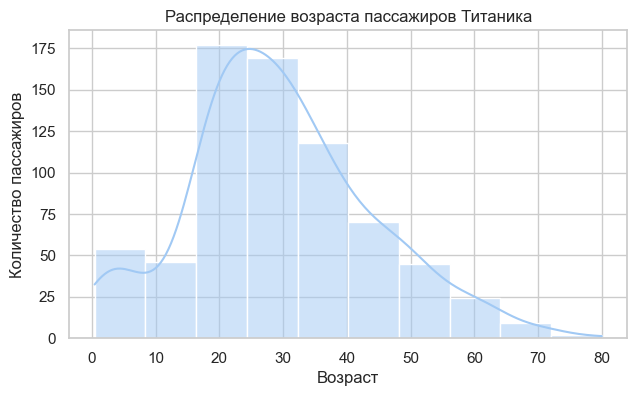

In [14]:
plt.figure(figsize=(7.2, 4))
sns.histplot(data=df, x='Age', bins=10, kde=True)
plt.title('Распределение возраста пассажиров Титаника')
plt.xlabel('Возраст')
plt.ylabel('Количество пассажиров')
plt.show()

 >#### Задание
>1) Измените количество бинов (и верните обратно). 
>2) Отключите плотность (и верните обратно). 
>3) Отключите палитру `pallete` (и верните обратно).

Примерно то же самое можно делать в matplotlib:

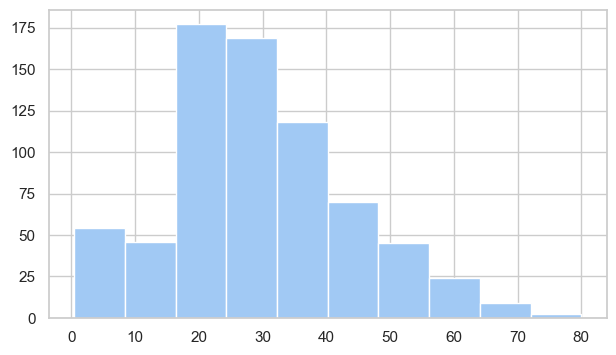

In [15]:
plt.figure(figsize=(7.2, 4))
plt.hist(df['Age'])
plt.show()

 >#### Вопрос
Есть гипотеза, что дети погибали чаще, чем взрослые. Верна ли эта гипотеза? Подсказка: используйте локализацию датафрейма по выжившим пассажирам (если кривые распределения будут вести себя примерно одинаково, то, скорее всего, гипотеза неверна). 

In [16]:
# Код

### Связь класса кают с возрастом

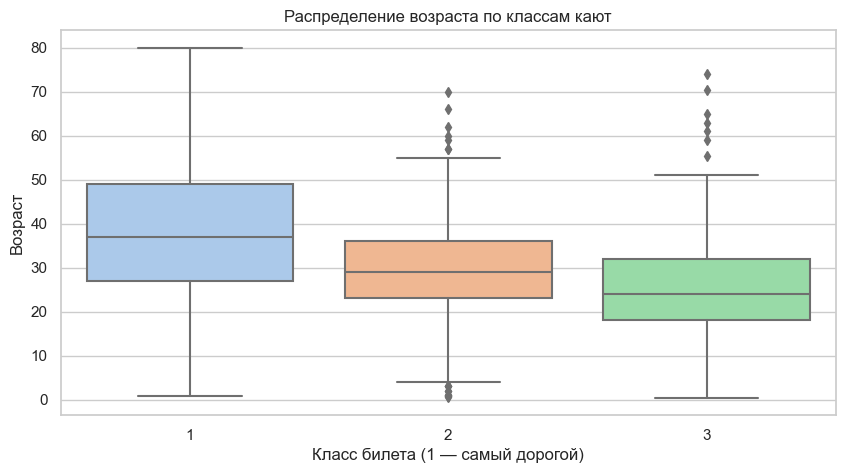

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title('Распределение возраста по классам кают')
plt.xlabel('Класс билета (1 — самый дорогой)')
plt.ylabel('Возраст')
plt.show()

Сделать это в matplotlib уже сложнее, поэтому не станем этого делать.

### Интерквартильный размах

Пусть $X$ — это какая-то случайная величина (можно считать, что это столбец датафрейма датафрейма).

$$
X = \{x_1, x_2, \dots, x_n\}\,.
$$

Упорядочиваем ее по возрастанию:

$$
X' = \{x'_1, x'_2, \dots, x'_n\}\,,\qquad x'_1<x'_2<\dots<x'_n\,.
$$

Отсчитываем слева первые 25\% наблюдений: это первый квартиль, или, что то же самое, двадцать пятый перцентиль. Отсчитываем слева первые 75\% наблюдений: это третий квартиль, или, что то же самое, семьдесят пятый перцентиль. Кстати, если отсчитать 50\%, то получится второй квартиль, или, что то же самое, пятидесятый перцентиль, а, проще говоря — медиана.

$$
Q_1 = x'_{0.25n}\,,\qquad  Q_3 = x'_{0.75n}\,.
$$

Разность между третьим и первый квартилями называется интерквартильным размахом. Вычисляем границы при помощи следующих формул:

$$
B^- = Q_1 - 1.5(Q_3 - Q_1)\,,\qquad B^+ = Q_3 + 1.5(Q_3 - Q_1)\,.
$$

Все значения, которые меньше нижней границы или больше верхней границы, считаем выбросами. Коэффициент 1.5, который при этом используется, никак теоретически не обоснован. Это эмпирическая формула.


>#### Задание
Визуализируйте распределение возраста по гендерной принадлежности.

In [18]:
# Код

### Стоимость билета, возраст и выживаемость

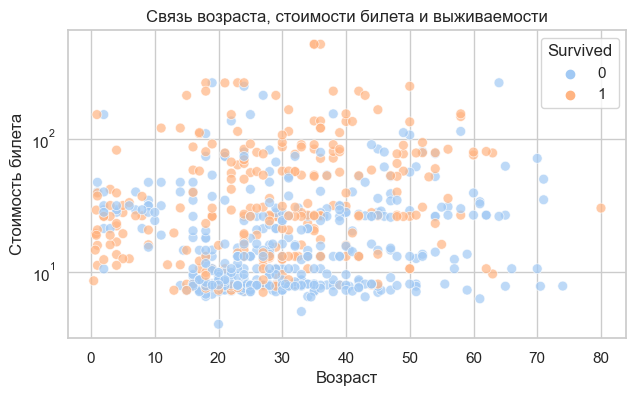

In [19]:
plt.figure(figsize=(7.2, 4))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7, s=50)
plt.title('Связь возраста, стоимости билета и выживаемости')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.yscale('log') # Использована логарифмическая шкала для наглядности, так как были очень дорогие билеты.
plt.show()

>#### Задание
>1) Отключите логарифмическю шкалу. Потом снова подключите. Сравните результаты.
>2) Сформулируйте гипотезу о социальном портрете погибших.

Примерно то же самое можно сделать в matplotlib. 

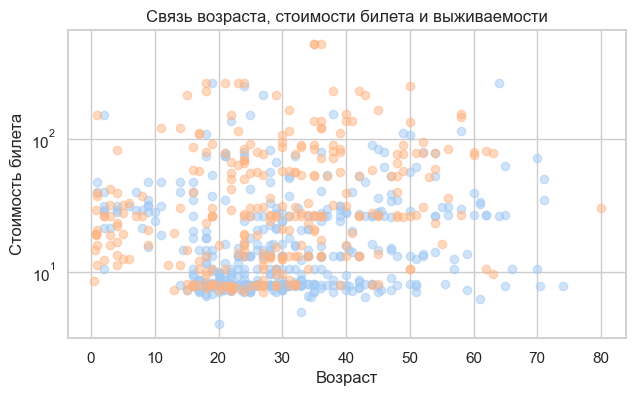

In [20]:
plt.figure(figsize=(7.2, 4))
plt.plot(df.loc[df['Survived'] == 0]['Age'], df.loc[df['Survived'] == 0]['Fare'], 'o', alpha = 0.5)
plt.plot(df.loc[df['Survived'] == 1]['Age'], df.loc[df['Survived'] == 1]['Fare'], 'o', alpha = 0.5)
plt.title('Связь возраста, стоимости билета и выживаемости')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.yscale('log') # Использована логарифмическая шкала для наглядности, так как были очень дорогие билеты.
plt.show()

Хотя, конечно, seaborn дает больше возможностей. Например параметр `hue` — это оттенок. Он задает не два цвета, а целый градиент, который описывается в виде числа в соответствующем столбце (просто в этой ситуации там всего два числа: 0 — погиб, 1 — выжил, промежуточных значений нет).

## § 5. Автоматизация

### Процент выживших по портам посадки

In [21]:
rate_list = []
port_list = df['Embarked'].dropna().unique()
for port in port_list:
    d = df.loc[df['Embarked'] == port]
    rate = d['Survived'].mean() * 100
    rate_list.append(rate)
    print('Порт', port, ': выжило', rate, '%') 

Порт S : выжило 33.69565217391305 %
Порт C : выжило 55.35714285714286 %
Порт Q : выжило 38.961038961038966 %


>#### Задание
Отключите подавление пропусков, и посмотрите, что получится. Потом подключите обратно.

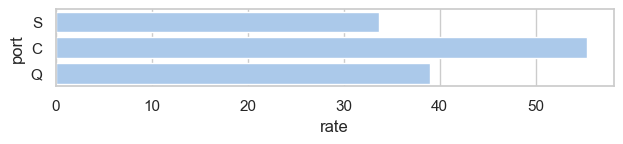

In [22]:
data = pd.DataFrame()
data['port'] = port_list
data['rate'] = rate_list

plt.figure(figsize=(7.2, 1))
sns.barplot(data=data, y='port', x='rate', orient='h', color = sns.color_palette()[0])
plt.show()

### Процент выживших по другим категориям

>#### Задание
>1) Проведите то же исследование по классам кают.
>1) И по половой принадлежности.

In [23]:
# Код

# Домашнее задание

## Визуализация
Визуализация играет важную роль сразу в двух смыслах (и именно поэтому ей следует владеть достаточно хорошо).

Во-первых, она помогает в процессе работы. Например, изменяя какой-то параметр в цикле, можно попытаться повлиять на качество модели. Если вывести просто список получающихся метрик как последовательность чисел, то это ничего не даст: чисел слишком много, сотни, или тысячи, и невозможно понять, какие именно значения изменяемого в цикле параметра приводили к успеху (а какие к провалу). Но если просто при помощи одной строчки нарисовать соответствующую кривую, не заботясь о ее внешнем виде, то стразу же станет все понятно. Это одноразовые картинки, которые нужны исследователю из соображений удобства. Грубо говоря, для это сгодится matplotlib (это не совсем так, но в поверхностном смысле — примерно так).

А во-вторых, визуализация важно на последнем этапе, когда работа уже выполнена, и нужно провести презентацию или подготовить отчет. Тогда картинки становятся очень важными, и приходится уделять эстетике и читаемости картинок очень много времени. Грубо говоря, для этого нужен seaborn (это тоже не совсем так, но для первоначального представления такое разделение годится).

>#### Задание
Изучите значения параметров `style` и `palette` в команде `sns.set(style = 'whitegrid', palette = 'pastel')` в преамбуле документа.

## Автоматизация

Если немного подумать, то станет понятно, что наиболее уязвимой частью пассажиров «Титаника» оказались бедные мужчины. В соответствии с этим, видимо, наиболее защищенными оказались богатые женщины (хотя, не факт). 

>#### Задание
По аналогии с предыдущим анализом проведите соответствующее исследование и вычислите проценты выживших в шести категориях — согласно трем классам кают и двум гендерам. Подсказка: поможет вложенный цикл.

In [24]:
# Код